# Limpieza y exploración de reseñas de restaurantes de Yelp

Este notebook prepara las reseñas para las siguientes etapas del proyecto de procesamiento de lenguaje natural. Primero se revisa la estructura y calidad del conjunto; después se normalizan los datos, se eliminan observaciones sospechosas y se estudian los patrones de ratings, volumen, longitud y evolución temporal.

El análisis sirve para conocer las características del conjunto antes de construir modelos y para dejar registradas las decisiones que pueden afectar a sus resultados.

## 1. Carga de datos

Se importan las herramientas necesarias y se lee el archivo de reseñas para trabajar con una tabla única durante todo el análisis. La primera visualización permite comprobar las columnas disponibles y hacerse una idea del contenido antes de transformarlo.

In [1]:
from urllib.parse import unquote

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [2]:
yelp_df = pd.read_csv('data/Yelp Restaurant Reviews.csv')
yelp_df

,Yelp URL,Rating,Date,Review Text
0,https://www.yelp.com/biz/sidney-dairy-barn-sidney,5,1/22/2022,All I can say is they have very good ice cream...
1,https://www.yelp.com/biz/sidney-dairy-barn-sidney,4,6/26/2022,Nice little local place for ice cream.My favor...
2,https://www.yelp.com/biz/sidney-dairy-barn-sidney,5,8/7/2021,A delicious treat on a hot day! Staff was very...
3,https://www.yelp.com/biz/sidney-dairy-barn-sidney,4,7/28/2016,This was great service and a fun crew! I got t...
4,https://www.yelp.com/biz/sidney-dairy-barn-sidney,5,6/23/2015,This is one of my favorite places to get ice c...
...,...,...,...,...
19891,https://www.yelp.com/biz/la-pasticceria-las-vegas,4,7/17/2021,Had the chocolate cannoli! The filling was ric...
19892,https://www.yelp.com/biz/la-pasticceria-las-vegas,4,10/21/2019,Love apricot croissant! I bought it at 4:00 PM...
19893,https://www.yelp.com/biz/la-pasticceria-las-vegas,4,10/12/2019,Line was about 25 people long. It went fast! T...
19894,https://www.yelp.com/biz/la-pasticceria-las-vegas,5,4/11/2021,Its hard not to order everything when I come h...


In [3]:
# El nombre se recupera del slug de la URL para disponer de una etiqueta uniforme.
yelp_df["Name"] = (
    yelp_df["Yelp URL"]
    .astype("string")
    .str.extract(r"/biz/([^/?#]+)", expand=False)   # slug del negocio
    .map(unquote, na_action="ignore")               # %C3%A9 -> é  (antes de limpiar)
    .str.replace(r"[-+_]", " ", regex=True)         # separadores -> espacio
    .str.replace(r"\d+", "", regex=True)            # fuera números
    .str.replace(r"[^\w\s]", "", regex=True)        # fuera caracteres especiales
    .str.replace(r"\s+", " ", regex=True)           # colapsa espacios
    .str.strip()
    .str.title()                                    # opcional: formato legible
)

## 2. Normalización del formato

Antes de analizar los datos se unifican los formatos de fecha, rating y texto. La conversión tolerante permite detectar valores que no siguen el formato esperado en lugar de interrumpir el proceso. Esos casos quedan marcados como nulos y se contabilizan más adelante para evaluar si afectan al conjunto.

In [4]:
fecha = pd.to_datetime(yelp_df["Date"], format="%m/%d/%Y", errors="coerce")
if fecha.isna().mean() > 0.05:
    fecha = pd.to_datetime(yelp_df["Date"], errors="coerce")
yelp_df["Date"] = fecha

In [5]:
yelp_df["Rating"] = pd.to_numeric(yelp_df["Rating"], errors="coerce")
yelp_df["Review Text"] = yelp_df["Review Text"].astype("string")

## 3. Creación de variables derivadas

Se enriquecen las reseñas con información que no aparece directamente en una sola columna. La longitud ayuda a describir el estilo de las opiniones; las variables temporales permiten observar cambios a lo largo del tiempo; y los indicadores de ratings extremos facilitan comparar la proporción de opiniones negativas y positivas.

Además, los nombres recuperados de las URL se resumen en un catálogo de restaurantes. Esto permite analizar cada negocio de forma consistente, incluso cuando su nombre contiene separadores, números o caracteres codificados.

In [6]:
# Atributos de longitud para describir la entrada textual.
yelp_df["n_chars"] = yelp_df["Review Text"].str.len()
yelp_df["n_words"] = yelp_df["Review Text"].str.split().str.len()

# Variables temporales para agregaciones por año, mes y día de la semana.
yelp_df["year"] = yelp_df["Date"].dt.year
yelp_df["month"] = yelp_df["Date"].dt.to_period("M").dt.to_timestamp()
yelp_df["dow"] = yelp_df["Date"].dt.dayofweek                       # 0 = lunes

# Indicadores binarios que resumen polaridad extrema del rating.
yelp_df["is_negative"] = yelp_df["Rating"].le(2)
yelp_df["is_positive"] = yelp_df["Rating"].ge(4)

In [7]:
# Catálogo agregado: una fila por restaurante para analizar cobertura y volumen.
catalogo = (
    yelp_df.groupby("Name")
           .agg(n_reviews=("Rating", "size"),
                media=("Rating", "mean"),
                primera=("Date", "min"),
                ultima=("Date", "max"))
           .sort_values("n_reviews", ascending=False)
           .reset_index()
)

# ID corto y estable para usar en tablas y visualizaciones.
catalogo["rid"] = ["R" + str(i + 1).zfill(3) for i in range(len(catalogo))]
catalogo = catalogo[["rid", "Name", "n_reviews", "media", "primera", "ultima"]]
yelp_df["rid"] = yelp_df["Name"].map(catalogo.set_index("Name")["rid"])

N_REST = len(catalogo)
print(f"Restaurantes: {N_REST} | Reseñas: {len(yelp_df)}")
print(f"Rango temporal: {yelp_df['Date'].min().date()} → {yelp_df['Date'].max().date()}\n")
print(catalogo.head(15).round(2).to_string(index=False))

Restaurantes: 49 | Reseñas: 19896
Rango temporal: 2005-06-24 → 2022-08-02

 rid                                             Name  n_reviews  media    primera     ultima
R001         Amélies French Bakery And Café Charlotte       2042   4.08 2008-08-07 2022-07-23
R002                         Bouchon Bakery Las Vegas       1386   4.00 2007-03-10 2022-07-26
R003                     Milk Bar Las Vegas Las Vegas       1333   3.45 2016-12-30 2022-07-30
R004                          Carlos Bakery Las Vegas       1290   2.98 2014-03-31 2022-07-14
R005                              Donut Bar Las Vegas       1280   4.28 2016-03-27 2022-07-30
R006                                    Churn Phoenix       1059   4.40 2011-04-25 2022-07-26
R007                          Novel Ice Cream Phoenix       1016   4.93 2017-02-28 2022-07-26
R008                    Sprinkles Las Vegas Las Vegas        965   3.87 2014-03-19 2022-03-22
R009                        Sweet Republic Scottsdale        899   4.39 2008-06

## 4. Control de integridad y duplicados

Antes de limpiar se comprueba si el conjunto puede utilizarse tal como está. Se revisan problemas habituales de una extracción web: fechas ilegibles o futuras, ratings ausentes o fuera de la escala, textos vacíos y nombres de negocio que no se hayan identificado correctamente.

También se buscan dos formas de repetición. La primera combina negocio, fecha y texto para localizar filas duplicadas dentro del mismo restaurante. La segunda busca exactamente el mismo texto en negocios distintos, ya que puede indicar contenido reutilizado o un artefacto del scraping. Estas comprobaciones se muestran antes de tomar la decisión de eliminar observaciones.

In [8]:
integridad = {
    "filas": len(yelp_df),
    "negocios únicos": yelp_df["Name"].nunique(),
    "fechas no parseadas (NaT)": int(yelp_df["Date"].isna().sum()),
    "ratings nulos": int(yelp_df["Rating"].isna().sum()),
    "reseñas vacías/nulas": int(yelp_df["Review Text"].isna().sum() + yelp_df["Review Text"].fillna("").str.strip().eq("").sum()),
    "fechas futuras": int((yelp_df["Date"] > pd.Timestamp.today()).sum()),
    "ratings fuera de [1,5]": int((~yelp_df["Rating"].between(1, 5)).sum()),
}
print(pd.Series(integridad).to_string(), "\n")

filas                        19896
negocios únicos                 49
fechas no parseadas (NaT)        0
ratings nulos                    0
reseñas vacías/nulas             0
fechas futuras                   0
ratings fuera de [1,5]           0 



In [9]:
dup_exactos = yelp_df.duplicated(subset=["Name", "Date", "Review Text"]).sum()
texto_repetido = (
    yelp_df.dropna(subset=["Review Text"])
      .groupby("Review Text")["Name"].nunique()
      .loc[lambda s: s > 1]
)
print(f"Reseñas duplicadas exactas (mismo negocio+fecha+texto): {dup_exactos}")
print(f"Textos idénticos que aparecen en >1 negocio (posible bot/scrape): {len(texto_repetido)}")
texto_repetido
 

Reseñas duplicadas exactas (mismo negocio+fecha+texto): 0
Textos idénticos que aparecen en >1 negocio (posible bot/scrape): 1


Review Text
#ERROR!    2
Name: Name, dtype: int64

In [10]:
yelp_df

,Yelp URL,Rating,Date,Review Text,Name,n_chars,n_words,year,month,dow,is_negative,is_positive,rid
0,https://www.yelp.com/biz/sidney-dairy-barn-sidney,5,2022-01-22,All I can say is they have very good ice cream...,Sidney Dairy Barn Sidney,123,26,2022,2022-01-01,5,False,True,R045
1,https://www.yelp.com/biz/sidney-dairy-barn-sidney,4,2022-06-26,Nice little local place for ice cream.My favor...,Sidney Dairy Barn Sidney,290,50,2022,2022-06-01,6,False,True,R045
2,https://www.yelp.com/biz/sidney-dairy-barn-sidney,5,2021-08-07,A delicious treat on a hot day! Staff was very...,Sidney Dairy Barn Sidney,131,26,2021,2021-08-01,5,False,True,R045
3,https://www.yelp.com/biz/sidney-dairy-barn-sidney,4,2016-07-28,This was great service and a fun crew! I got t...,Sidney Dairy Barn Sidney,374,72,2016,2016-07-01,3,False,True,R045
4,https://www.yelp.com/biz/sidney-dairy-barn-sidney,5,2015-06-23,This is one of my favorite places to get ice c...,Sidney Dairy Barn Sidney,848,172,2015,2015-06-01,1,False,True,R045
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19891,https://www.yelp.com/biz/la-pasticceria-las-vegas,4,2021-07-17,Had the chocolate cannoli! The filling was ric...,La Pasticceria Las Vegas,120,21,2021,2021-07-01,5,False,True,R047
19892,https://www.yelp.com/biz/la-pasticceria-las-vegas,4,2019-10-21,Love apricot croissant! I bought it at 4:00 PM...,La Pasticceria Las Vegas,352,69,2019,2019-10-01,0,False,True,R047
19893,https://www.yelp.com/biz/la-pasticceria-las-vegas,4,2019-10-12,Line was about 25 people long. It went fast! T...,La Pasticceria Las Vegas,356,61,2019,2019-10-01,5,False,True,R047
19894,https://www.yelp.com/biz/la-pasticceria-las-vegas,5,2021-04-11,Its hard not to order everything when I come h...,La Pasticceria Las Vegas,168,31,2021,2021-04-01,6,False,True,R047


## 5. Limpieza del texto

Se retiran los textos que aparecen asociados a más de un restaurante. En este conjunto, esa pauta se considera más probable que corresponda a contenido repetido o a un problema de extracción que a reseñas independientes.

La eliminación se hace sobre una copia filtrada y se informa del número de filas que permanece. Así se puede valorar cuánto cambia el conjunto y comparar posteriormente los resultados con la versión original.

In [11]:
texto_repetido_idx = texto_repetido.index
yelp_df = yelp_df[~yelp_df["Review Text"].isin(texto_repetido_idx)].copy()

print(f"Filas restantes en yelp_df: {len(yelp_df)}")

Filas restantes en yelp_df: 19894


## 6. Distribución del volumen por restaurante

Aquí se estudia cómo se reparte la cantidad de reseñas entre los restaurantes. Las barras están ordenadas de mayor a menor para hacer visible si unos pocos negocios concentran gran parte del conjunto y si existe una cola de restaurantes con muy poca información.

Se presta especial atención a dos señales. Si muchos restaurantes tienen exactamente el mismo número máximo de reseñas, podría haberse aplicado un límite durante la extracción.

También se calcula la proporción acumulada del volumen para saber cuántos restaurantes reúnen el 80 % de las reseñas. En este notebook esa proporción se usa para obtener el número de restaurantes y no se representa en una curva. Como el catálogo se construyó antes del filtrado de textos repetidos, las barras describen el volumen original.

count      49.000000
mean      406.040816
std       457.416338
min        13.000000
25%        97.000000
50%       247.000000
75%       486.000000
max      2042.000000

Máximo de reseñas: 2042 | restaurantes exactamente en el tope: 2.0%


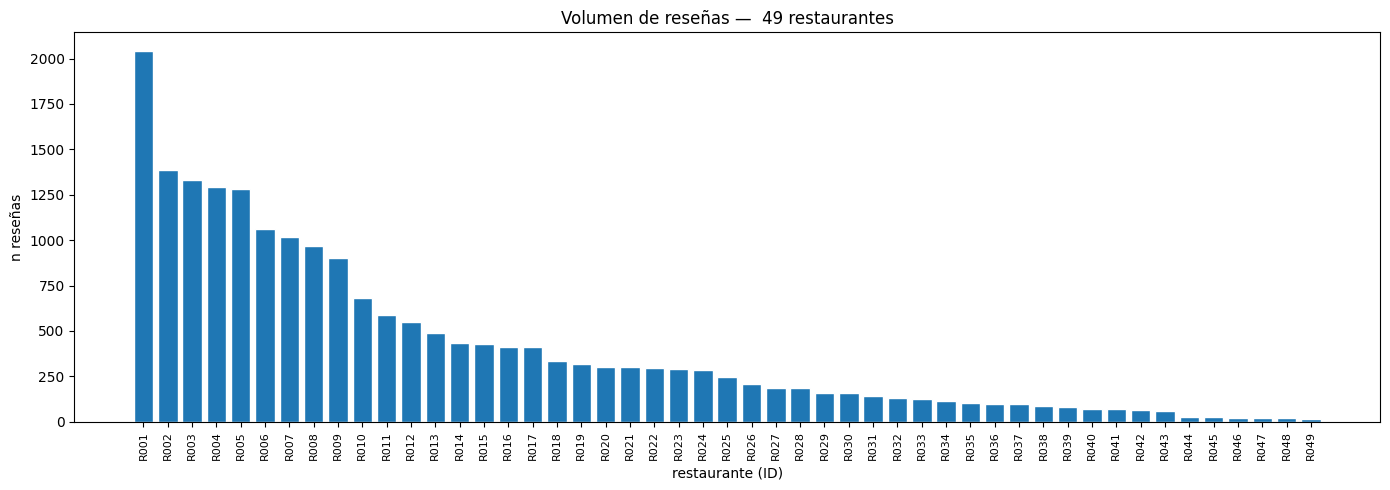


20 restaurantes (40.8%) concentran el 80% de las reseñas.
Cola: restaurantes con menos de 10 reseñas → 0 (0.0%). Sus medias son ruido.


In [12]:
vol = catalogo.set_index("rid")["n_reviews"]
 
print(vol.describe().to_string())
tope = vol.max()
share_tope = (vol == tope).mean()
print(f"\nMáximo de reseñas: {tope} | restaurantes exactamente en el tope: {share_tope:.1%}")
 
sub = vol.head(N_REST)
acum = vol.cumsum() / vol.sum() * 100
 
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(sub.index, sub.values, edgecolor="white")
ax.set_ylabel("n reseñas"); ax.set_xlabel("restaurante (ID)")
ax.set_title(f"Volumen de reseñas —  {N_REST} restaurantes")
ax.tick_params(axis="x", rotation=90, labelsize=8)
 
plt.tight_layout(); plt.show()
 
n80 = int((acum <= 80).sum()) + 1
print(f"\n{n80} restaurantes ({n80/N_REST:.1%}) concentran el 80% de las reseñas.")
print("Cola: restaurantes con menos de 10 reseñas → "
      f"{(vol < 10).sum()} ({(vol < 10).mean():.1%}). Sus medias son ruido.")

## 7. Distribución de ratings y longitud de las reseñas

Se observa la forma de la variable de valoración, su posible desequilibrio y la extensión de los textos. Las ratings se resumen por número de estrellas y las reseñas se agrupan por intervalos de palabras para que sea sencillo distinguir el comportamiento habitual de los textos muy cortos o muy largos.

La cantidad de reseñas por año aporta el contexto temporal de la muestra. En conjunto, estas vistas ayudan a decidir cómo interpretar la variable objetivo y qué transformaciones podrían ser necesarias antes del modelado.

Media global: 4.131 | % 1–2★: 12.6% | % 4–5★: 77.0%



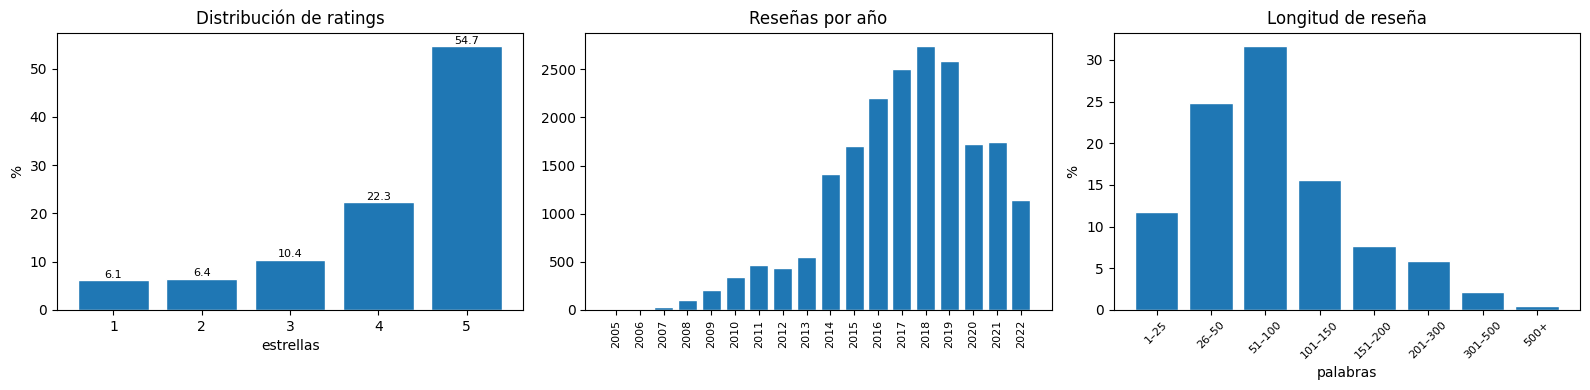

In [13]:
C = yelp_df["Rating"].mean()
dist = yelp_df["Rating"].value_counts(normalize=True).sort_index() * 100
 
print(f"Media global: {C:.3f} | % 1–2★: {yelp_df['is_negative'].mean():.1%} | "
      f"% 4–5★: {yelp_df['is_positive'].mean():.1%}\n")
 
# Longitud en buckets ordenados → barras, no histograma
bins = [0, 25, 50, 100, 150, 200, 300, 500, np.inf]
etiquetas = ["1–25", "26–50", "51–100", "101–150", "151–200", "201–300", "301–500", "500+"]
yelp_df["bucket_words"] = pd.cut(yelp_df["n_words"], bins=bins, labels=etiquetas)
buckets = yelp_df["bucket_words"].value_counts(normalize=True).reindex(etiquetas) * 100
 
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].bar(dist.index.astype(str), dist.values, edgecolor="white")
ax[0].set_title("Distribución de ratings"); ax[0].set_xlabel("estrellas"); ax[0].set_ylabel("%")
for i, v in enumerate(dist.values):
    ax[0].text(i, v + .5, f"{v:.1f}", ha="center", fontsize=8)
 
anual = yelp_df["year"].value_counts().sort_index()
ax[1].bar(anual.index.astype(int).astype(str), anual.values, edgecolor="white")
ax[1].set_title("Reseñas por año"); ax[1].tick_params(axis="x", rotation=90, labelsize=8)
 
ax[2].bar(buckets.index.astype(str), buckets.values, edgecolor="white")
ax[2].set_title("Longitud de reseña"); ax[2].set_xlabel("palabras"); ax[2].set_ylabel("%")
ax[2].tick_params(axis="x", rotation=45, labelsize=8)
plt.tight_layout(); plt.show()

## 8. Comparación entre restaurantes

Se comparan los negocios desde varias perspectivas: cuántas reseñas tienen, cuál es su valoración media, cuánto varían sus ratings, qué proporción es negativa y qué longitud suelen tener sus textos. Esto evita juzgar un restaurante únicamente por su media, especialmente cuando esa media procede de muy pocas opiniones.

### Suavizado aplicado a este conjunto

Para hacer la comparación más prudente se aplica un suavizado hacia la media global. En los datos actuales, la referencia global es aproximadamente 4.131 `C = 4.131` estrellas y el peso utilizado corresponde a 247 `m = 247`reseñas, la mediana del volumen por restaurante. Puede interpretarse como una cantidad de evidencia de referencia: un restaurante con pocos datos se acerca más al promedio general, mientras que uno con muchas reseñas conserva principalmente su propia media.

El cálculo de `media_bayes` corrige la interpretación de medias calculadas con pocas reseñas. La fórmula utilizada es:

$$
\text{media\_bayes} = \frac{n \cdot \text{media} + 247 \cdot 4.131}{n + 247}
$$

En esta fórmula, `247 · 4.131` funciona como una referencia equivalente a 247 reseñas con rating medio 4.131. A esta referencia se le llama **prior**. Es una forma de expresar que, cuando un restaurante tiene pocos datos, su media es menos confiable.

Por ejemplo, un restaurante con 10 reseñas y media observada de 5 estrellas queda así:

$$
\frac{10 \cdot 5 + 247 \cdot 4.131}{10 + 247} \approx 4.165
$$

Su media se acerca a 4.131 porque solo hay 10 reseñas. En cambio, si otro restaurante tiene 1.000 reseñas y media 5:

$$
\frac{1000 \cdot 5 + 247 \cdot 4.131}{1000 + 247} \approx 4.828
$$

En este segundo caso los datos propios pesan mucho más, por lo que la media suavizada permanece cerca de 5. La columna `ajuste` muestra la diferencia entre `media_bayes` y la media original.


Finalmente, el gráfico apilado no representa la media suavizada: muestra, para cada restaurante, qué porcentaje de sus reseñas tiene 1, 2, 3, 4 o 5 estrellas. Así se puede ver si una media procede de valoraciones concentradas o de una mezcla de puntuaciones.

Prior C = 4.131 | peso m = 247 reseñas
Ajuste medio absoluto del shrinkage: 0.211★
Restaurantes con ajuste > 0.5★: 4



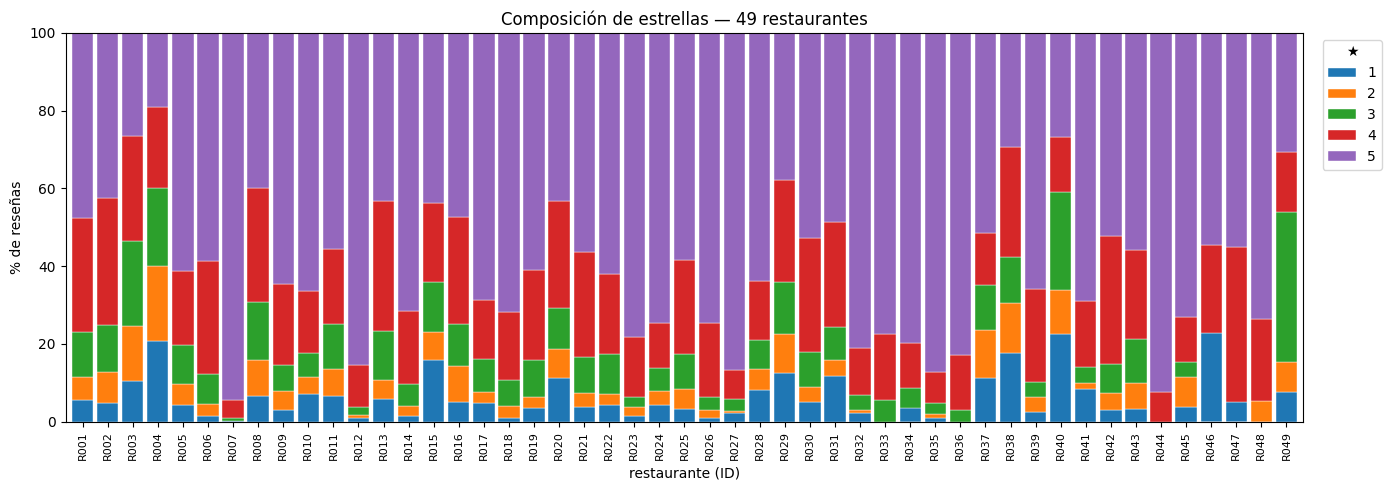

In [14]:
negocios = yelp_df.groupby("rid").agg(
    n=("Rating", "size"), media=("Rating", "mean"), sd=("Rating", "std"),
    pct_neg=("is_negative", "mean"), palabras_med=("n_words", "median"),
)
m = negocios["n"].median()

# Suavizado bayesiano: las medias de muestras pequeñas se acercan a la media global.
negocios["media_bayes"] = (negocios["n"] * negocios["media"] + m * C) / (negocios["n"] + m)
negocios["ajuste"] = negocios["media_bayes"] - negocios["media"]

print(f"Prior C = {C:.3f} | peso m = {m:.0f} reseñas")
print(f"Ajuste medio absoluto del shrinkage: {negocios['ajuste'].abs().mean():.3f}★")
print(f"Restaurantes con ajuste > 0.5★: {(negocios['ajuste'].abs() > .5).sum()}\n")

# Se ordenan por volumen para comparar primero los negocios con más evidencia.
orden = negocios.nlargest(N_REST, "n").index
mix = (pd.crosstab(yelp_df["rid"], yelp_df["Rating"], normalize="index") * 100).loc[orden]

fig, ax = plt.subplots(figsize=(14, 5))
mix.plot(kind="bar", stacked=True, ax=ax, edgecolor="white", linewidth=.3, width=.85)
ax.set_title(f"Composición de estrellas — {N_REST} restaurantes")
ax.set_ylabel("% de reseñas"); ax.set_xlabel("restaurante (ID)"); ax.set_ylim(0, 100)
ax.legend(title="★", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.tick_params(axis="x", rotation=90, labelsize=8)
plt.tight_layout(); plt.show()

## 9. Evolución mensual de las reseñas

Se observa la actividad del conjunto mes a mes para distinguir cambios en la cantidad de opiniones de cambios en su valoración. El panel superior muestra el volumen mensual y ayuda a localizar periodos de mayor o menor actividad.

El panel inferior representa el rating medio de los meses con suficiente información. Se exige un mínimo de 20 reseñas para que un único rating no determine prácticamente toda la media de un mes. La línea horizontal marca la media global y permite valorar cada mes en relación con el comportamiento general.

La franja roja señala el intervalo elegido para identificar el periodo de pandemia. Se trata de una referencia temporal para comparar el patrón de la muestra, no de una prueba de que ese acontecimiento explique por sí solo cualquier variación observada.

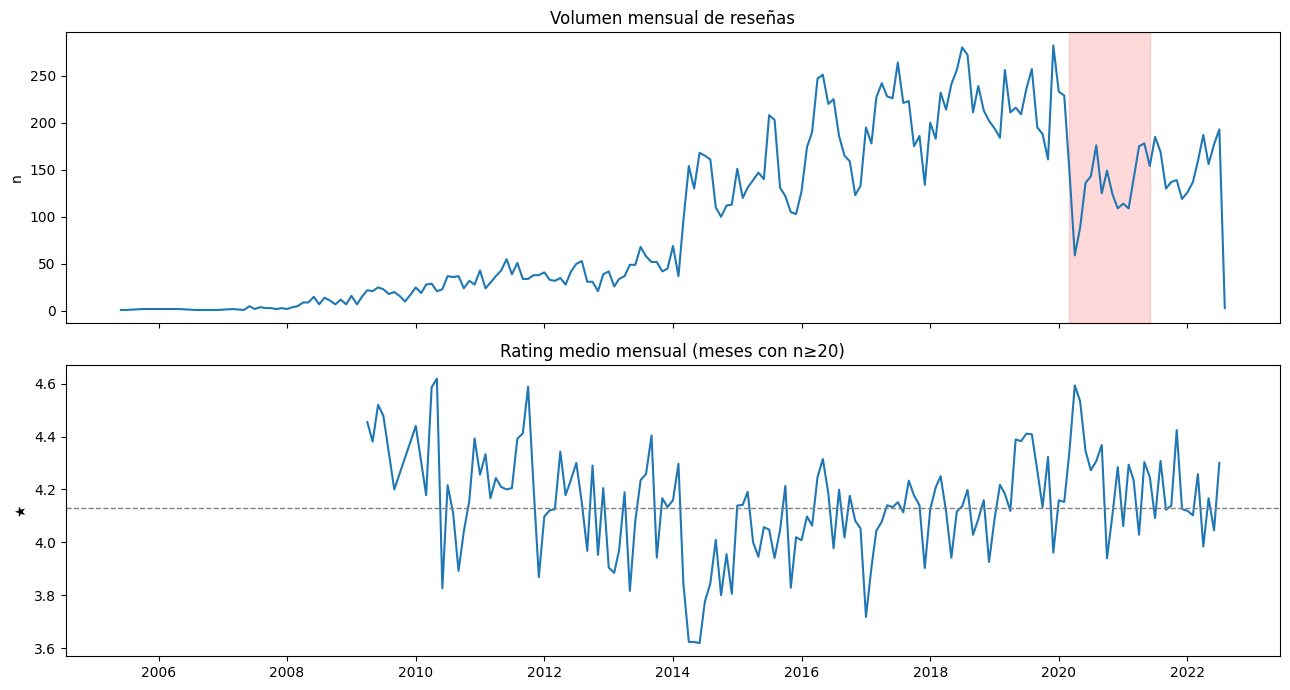

In [15]:
mensual = yelp_df.groupby("month").agg(n=("Rating", "size"), media=("Rating", "mean"))
mensual_est = mensual[mensual["n"] >= 20]
 
fig, ax = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
ax[0].plot(mensual.index, mensual["n"])
ax[0].axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-06-01"), alpha=.15, color="red")
ax[0].set_title("Volumen mensual de reseñas"); ax[0].set_ylabel("n")
ax[1].plot(mensual_est.index, mensual_est["media"])
ax[1].axhline(C, ls="--", lw=1, color="gray")
ax[1].set_title("Rating medio mensual (meses con n≥20)"); ax[1].set_ylabel("★")
plt.tight_layout(); plt.show()

## 10. Composición anual y comparación por periodos

El gráfico anual permite comprobar si el perfil de las valoraciones cambia con el tiempo. Cada barra representa un año y está normalizada al 100 %, de modo que se compara la proporción de ratings de 1 a 5 estrellas dentro de cada año, no el número total de reseñas. Por eso, un año con una barra más pequeña en el conjunto no aparece necesariamente más pequeño en este gráfico.

Para resumir cambios relacionados con fechas relevantes, se divide el intervalo observado en tres etapas: antes de marzo de 2020, el periodo comprendido entre marzo de 2020 y junio de 2021, y el periodo posterior. Estas fronteras son decisiones analíticas del proyecto y permiten una comparación descriptiva, pero no establecen una relación causal.

La tabla final contrasta las etapas mediante el número de reseñas, el rating medio, la proporción de ratings negativos y la longitud mediana de las opiniones. Así se puede comprobar si las diferencias se producen solo en las valoraciones o también en el volumen y en la forma de escribir las reseñas.

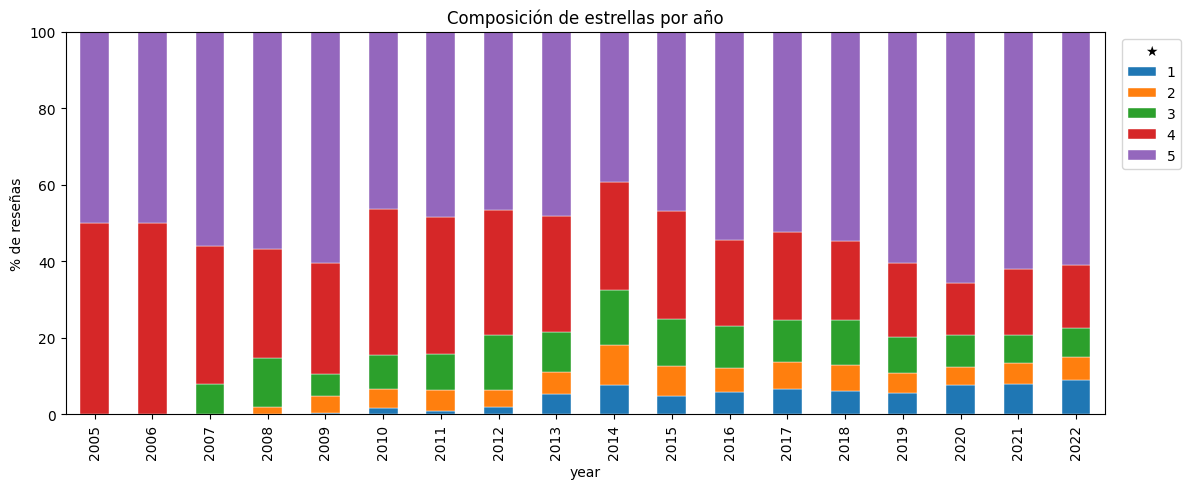

                n  media  pct_neg  palabras
periodo                                    
1_pre_2020  15748  4.110    0.123      71.0
2_pandemia   1975  4.246    0.131      57.0
3_post       2171  4.174    0.140      57.0 



In [16]:
mix_anual = pd.crosstab(yelp_df["year"], yelp_df["Rating"], normalize="index") * 100
fig, ax = plt.subplots(figsize=(12, 5))
mix_anual.plot(kind="bar", stacked=True, ax=ax, edgecolor="white", linewidth=.3)
ax.set_title("Composición de estrellas por año"); ax.set_ylabel("% de reseñas")
ax.set_ylim(0, 100); ax.legend(title="★", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout(); plt.show()
 
def periodo(d):
    if pd.isna(d):                       return np.nan
    if d < pd.Timestamp("2020-03-01"):   return "1_pre_2020"
    if d < pd.Timestamp("2021-06-01"):   return "2_pandemia"
    return "3_post"
 
yelp_df["periodo"] = yelp_df["Date"].map(periodo)
print(yelp_df.groupby("periodo").agg(
    n=("Rating", "size"), media=("Rating", "mean"),
    pct_neg=("is_negative", "mean"), palabras=("n_words", "median")).round(3).to_string(), "\n")

## 12. Guardar archivo csv


In [17]:
ruta_salida = "data/Yelp Restaurant Reviews_clean.csv"

yelp_df.to_csv(ruta_salida, index=False, encoding="utf-8-sig")

print(f"Archivo guardado en: {ruta_salida}")
print(f"Filas: {len(yelp_df):,} | Columnas: {len(yelp_df.columns)}")

Archivo guardado en: data/Yelp Restaurant Reviews_clean.csv
Filas: 19,894 | Columnas: 15


## 12. Conclusiones

- El conjunto de datos contiene 19.896 reseñas de 49 restaurantes y no se detectaron fechas ilegibles, ratings nulos, ratings fuera de la escala, textos vacíos ni fechas futuras. Tampoco hay duplicados exactos. Solo se identificó un texto repetido entre dos restaurantes (`#ERROR!`), que se elimina como posible artefacto de extracción.

- Las valoraciones están desbalanceadas hacia opiniones positivas, la media global es 4,131 estrellas; el 54,7 % de las reseñas tiene 5 estrellas y el 22,3 % tiene 4. En cambio, solo el 12,6 % corresponde a ratings de 1 o 2 estrellas. Para un modelo de clasificación, la exactitud por sí sola puede resultar engañosa; será necesario comparar también precisión, recall, F1 y, si procede, métricas por clase.

- El volumen está concentrado, los restaurantes tienen una mediana de 247 reseñas, pero el rango va de 13 a 2.042. Solo 20 de los 49 restaurantes (40,8 %) reúnen el 80 % de las reseñas. Por tanto, los resultados globales estarán más influidos por los negocios con mayor volumen que por los restaurantes pequeños.

- La actividad cambia con el tiempo el número de reseñas aumenta progresivamente hasta alcanzar sus niveles más altos aproximadamente entre 2016 y 2019. Durante el periodo marcado como pandemia se observa una caída brusca del volumen mensual. Después, la actividad se recupera parcialmente, aunque no vuelve a mostrar exactamente el mismo patrón.

- Las valoraciones también varían entre periodos la media pasa de 4,110 antes de 2020 a 4,246 durante el periodo definido como pandemia y 4,174 después. Al mismo tiempo, la proporción de ratings negativos sube de 12,3 % a 13,1 % y 14,0 %, respectivamente. Esto sugiere que el volumen y la valoración no se mueven necesariamente en la misma dirección.

- Las reseñas son más cortas en los periodos recientes, la mediana pasa de 71 palabras antes de 2020 a 57 durante la pandemia y después. Esta diferencia puede afectar a las características textuales y debe tenerse en cuenta al comparar modelos entre periodos.